## Data Cleaning and Preparation

Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import datetime as dt
import time
import yfinance as yf
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

# ── Local path — adjust to wherever your CSVs live ───────────────────────────
project_root = '/Users/vando/Documents/USC/Career Center/Robinhood-Engagement-Analytics-1'
data_path = os.path.join(project_root, 'popularity_export')
print(f'Using project root: {project_root}')

print('Setup complete.')

Using project root: /Users/vando/Documents/USC/Career Center/Robinhood-Engagement-Analytics-1
Setup complete.


In [4]:
%%time
sorted(os.listdir(data_path))

CPU times: user 3.82 ms, sys: 7.59 ms, total: 11.4 ms
Wall time: 11.8 ms


['A.csv',
 'AA.csv',
 'AAAU.csv',
 'AACAY.csv',
 'AACG.csv',
 'AADR.csv',
 'AAGIY.csv',
 'AAL.csv',
 'AAMC.csv',
 'AAME.csv',
 'AAN.csv',
 'AAOI.csv',
 'AAON.csv',
 'AAP.csv',
 'AAPL.csv',
 'AAT.csv',
 'AAU.csv',
 'AAWW.csv',
 'AAXJ.csv',
 'AAXN.csv',
 'AB.csv',
 'ABAX.csv',
 'ABB.csv',
 'ABBV.csv',
 'ABC.csv',
 'ABCB.csv',
 'ABCD.csv',
 'ABDC.csv',
 'ABEO.csv',
 'ABEQ.csv',
 'ABEV.csv',
 'ABG.csv',
 'ABIO.csv',
 'ABM.csv',
 'ABMD.csv',
 'ABR.csv',
 'ABT.csv',
 'ABTX.csv',
 'ABUS.csv',
 'AC.csv',
 'ACA.csv',
 'ACAD.csv',
 'ACAM.csv',
 'ACB.csv',
 'ACBI.csv',
 'ACC.csv',
 'ACCD.csv',
 'ACCO.csv',
 'ACEL.csv',
 'ACER.csv',
 'ACES.csv',
 'ACGBY.csv',
 'ACGL.csv',
 'ACH.csv',
 'ACHC.csv',
 'ACHN.csv',
 'ACHV.csv',
 'ACI.csv',
 'ACIA.csv',
 'ACIO.csv',
 'ACIU.csv',
 'ACIW.csv',
 'ACLS.csv',
 'ACM.csv',
 'ACMR.csv',
 'ACN.csv',
 'ACNB.csv',
 'ACOR.csv',
 'ACP.csv',
 'ACRE.csv',
 'ACRS.csv',
 'ACRX.csv',
 'ACSAY.csv',
 'ACSG.csv',
 'ACSI.csv',
 'ACST.csv',
 'ACT.csv',
 'ACTG.csv',
 'ACTT.csv'

In [5]:
data = pd.read_csv(os.path.join(data_path, 'A.csv'))
data.head()

,timestamp,users_holding
0,2018-05-02 04:56:43,590
1,2018-05-02 06:41:54,590
2,2018-05-03 00:38:56,586
3,2018-05-03 06:37:13,586
4,2018-05-03 06:52:09,586


**Daily Robinhood Users Holding Summary Statistics**

In [8]:
import time


start = time.time()

user_holdings = []

for ticker in sorted(os.listdir(data_path)):
    # After doing some manual searching, we find some erroneous tickers and we do not include them
    ticker = ticker[:-4]
    data = pd.read_csv(os.path.join(data_path, '{}.csv'.format(ticker)),
                   parse_dates=['timestamp'],
                   index_col=0)\
                            .resample('D').mean()\
                            .rename(columns={'users_holding':'{}_avg_users_holding'.format(ticker)})

    user_holdings.append(data)

daily_holdings_of_all_stocks = pd.concat(user_holdings, axis=1)
daily_holdings_of_all_stocks.index.name = 'Date'

end = time.time()

print(f'The code takes {(end-start)/60} minutes to run.')

The code takes 1.4289021015167236 minutes to run.


In [9]:
daily_holdings_of_all_stocks

,A_avg_users_holding,AA_avg_users_holding,AAAU_avg_users_holding,AACAY_avg_users_holding,AACG_avg_users_holding,AADR_avg_users_holding,AAGIY_avg_users_holding,AAL_avg_users_holding,AAMC_avg_users_holding,AAME_avg_users_holding,...,ZTS_avg_users_holding,ZUMZ_avg_users_holding,ZUO_avg_users_holding,ZURVY_avg_users_holding,ZVO_avg_users_holding,ZYME_avg_users_holding,ZYNE_avg_users_holding,ZYXI_avg_users_holding,_OUT_avg_users_holding,_PRN_avg_users_holding
Date,,,,,,,,,,,,,,,,,,,,,
2018-05-02,590.000000,NaN,NaN,NaN,55.000000,NaN,NaN,3755.000000,NaN,119.000000,...,588.000000,248.000000,539.000000,NaN,NaN,NaN,6127.000000,NaN,158.000000,12.000000
2018-05-03,586.473684,NaN,NaN,NaN,55.473684,NaN,NaN,3778.368421,NaN,118.315789,...,610.421053,250.052632,544.423077,NaN,NaN,NaN,6137.052632,NaN,156.263158,12.000000
2018-05-04,587.458333,NaN,NaN,NaN,55.458333,NaN,NaN,3762.750000,NaN,119.000000,...,608.083333,249.166667,547.739130,NaN,NaN,NaN,6145.416667,NaN,154.000000,12.000000
2018-05-05,588.000000,NaN,NaN,NaN,56.000000,NaN,NaN,3748.000000,NaN,119.000000,...,607.000000,247.000000,550.000000,NaN,NaN,NaN,6140.000000,NaN,154.000000,12.000000
2018-05-06,588.000000,NaN,NaN,NaN,56.000000,NaN,NaN,3748.000000,NaN,119.000000,...,607.000000,247.000000,550.000000,NaN,NaN,NaN,6140.000000,NaN,154.000000,12.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-09,1616.000000,5678.000000,1727.000000,361.000000,1664.000000,13.0,334.000000,641785.000000,89.000000,260.000000,...,2735.000000,494.000000,6202.000000,231.000000,5806.000000,674.000000,32097.000000,3192.000000,2021.000000,23.000000
2020-08-10,1619.208333,5668.750000,1735.041667,360.125000,1658.791667,13.0,334.166667,640821.833333,88.375000,259.333333,...,2736.208333,498.041667,6224.458333,230.333333,5759.166667,673.208333,32060.833333,3186.916667,2017.041667,23.416667
2020-08-11,1625.500000,5683.166667,1732.833333,358.583333,1647.458333,13.0,334.625000,639770.583333,87.250000,255.958333,...,2732.416667,502.666667,6308.166667,228.416667,5635.833333,674.875000,31939.875000,3170.041667,2002.500000,24.000000


In [14]:
daily_holdings_of_all_stocks.to_csv(os.path.join(project_root, 'avg_daily_rh_user_holding.csv'))

In [ ]:
daily_holdings_of_all_stocks = pd.read_csv(os.path.join(project_root, 'avg_daily_rh_user_holding.csv'))

daily_holdings_of_all_stocks['Date'] = pd.to_datetime(daily_holdings_of_all_stocks['Date'])
daily_holdings_of_all_stocks.set_index('Date', inplace=True)
daily_holdings_of_all_stocks.sort_index(inplace=True)

daily_holdings_of_all_stocks

,A_avg_users_holding,AA_avg_users_holding,AAAU_avg_users_holding,AACAY_avg_users_holding,AACG_avg_users_holding,AADR_avg_users_holding,AAGIY_avg_users_holding,AAL_avg_users_holding,AAMC_avg_users_holding,AAME_avg_users_holding,...,ZTS_avg_users_holding,ZUMZ_avg_users_holding,ZUO_avg_users_holding,ZURVY_avg_users_holding,ZVO_avg_users_holding,ZYME_avg_users_holding,ZYNE_avg_users_holding,ZYXI_avg_users_holding,_OUT_avg_users_holding,_PRN_avg_users_holding
Date,,,,,,,,,,,,,,,,,,,,,
2018-05-02,590.000000,NaN,NaN,NaN,55.000000,NaN,NaN,3755.000000,NaN,119.000000,...,588.000000,248.000000,539.000000,NaN,NaN,NaN,6127.000000,NaN,158.000000,12.000000
2018-05-03,586.473684,NaN,NaN,NaN,55.473684,NaN,NaN,3778.368421,NaN,118.315789,...,610.421053,250.052632,544.423077,NaN,NaN,NaN,6137.052632,NaN,156.263158,12.000000
2018-05-04,587.458333,NaN,NaN,NaN,55.458333,NaN,NaN,3762.750000,NaN,119.000000,...,608.083333,249.166667,547.739130,NaN,NaN,NaN,6145.416667,NaN,154.000000,12.000000
2018-05-05,588.000000,NaN,NaN,NaN,56.000000,NaN,NaN,3748.000000,NaN,119.000000,...,607.000000,247.000000,550.000000,NaN,NaN,NaN,6140.000000,NaN,154.000000,12.000000
2018-05-06,588.000000,NaN,NaN,NaN,56.000000,NaN,NaN,3748.000000,NaN,119.000000,...,607.000000,247.000000,550.000000,NaN,NaN,NaN,6140.000000,NaN,154.000000,12.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-09,1616.000000,5678.000000,1727.000000,361.000000,1664.000000,13.0,334.000000,641785.000000,89.000000,260.000000,...,2735.000000,494.000000,6202.000000,231.000000,5806.000000,674.000000,32097.000000,3192.000000,2021.000000,23.000000
2020-08-10,1619.208333,5668.750000,1735.041667,360.125000,1658.791667,13.0,334.166667,640821.833333,88.375000,259.333333,...,2736.208333,498.041667,6224.458333,230.333333,5759.166667,673.208333,32060.833333,3186.916667,2017.041667,23.416667
2020-08-11,1625.500000,5683.166667,1732.833333,358.583333,1647.458333,13.0,334.625000,639770.583333,87.250000,255.958333,...,2732.416667,502.666667,6308.166667,228.416667,5635.833333,674.875000,31939.875000,3170.041667,2002.500000,24.000000


**Top 6 Stocks**

In [12]:
top_6_stocks = daily_holdings_of_all_stocks\
              .iloc[-1, :]\
              .dropna()\
              .sort_values(ascending=False)\
              .iloc[0:6]

top_6_stocks

F_avg_users_holding       913120.65
GE_avg_users_holding      857936.80
AAPL_avg_users_holding    720905.50
MSFT_avg_users_holding    654239.60
AAL_avg_users_holding     638793.60
DIS_avg_users_holding     598965.40
Name: 2020-08-13 00:00:00, dtype: float64

In [13]:
daily_holdings_of_top_6_stocks = daily_holdings_of_all_stocks.loc[:, top_6_stocks.index]

daily_holdings_of_top_6_stocks

,F_avg_users_holding,GE_avg_users_holding,AAPL_avg_users_holding,MSFT_avg_users_holding,AAL_avg_users_holding,DIS_avg_users_holding
Date,,,,,,
2018-05-02,131071.000000,134735.000000,150785.000000,112514.000000,3755.000000,59936.000000
2018-05-03,131226.842105,134576.105263,144779.052632,113103.631579,3778.368421,60186.421053
2018-05-04,130959.583333,134573.125000,142690.875000,112515.083333,3762.750000,60319.166667
2018-05-05,130621.666667,134446.500000,141428.000000,112007.000000,3748.000000,60117.666667
2018-05-06,130623.000000,134447.125000,141436.916667,112007.000000,3748.000000,60119.000000
...,...,...,...,...,...,...
2020-08-09,920470.000000,860703.000000,683300.000000,643729.000000,641785.000000,603808.000000
2020-08-10,918952.750000,860856.458333,688717.500000,645807.500000,640821.833333,603214.458333
2020-08-11,915765.083333,860064.458333,701134.500000,651363.750000,639770.583333,601230.500000


In [16]:
stocks_to_slice = top_6_stocks.index.tolist() + ['SPY_avg_users_holding']

daily_holdings_of_top_stocks = daily_holdings_of_all_stocks.loc[:, stocks_to_slice]

daily_growth_rate_of_top_stocks = daily_holdings_of_top_stocks.pct_change(fill_method=None).dropna()

daily_growth_rate_of_top_stocks.columns = [col.split('_')[0] + '_avg_growth_rate_users' for col in daily_growth_rate_of_top_stocks.columns]

daily_growth_rate_of_top_stocks

,F_avg_growth_rate_users,GE_avg_growth_rate_users,AAPL_avg_growth_rate_users,MSFT_avg_growth_rate_users,AAL_avg_growth_rate_users,DIS_avg_growth_rate_users,SPY_avg_growth_rate_users
Date,,,,,,,
2018-05-03,0.001189,-1.179313e-03,-0.039831,0.005241,0.006223,0.004178,0.006993
2018-05-04,-0.002037,-2.214556e-05,-0.014423,-0.005204,-0.004134,0.002206,-0.001533
2018-05-16,-0.000867,2.322818e-03,0.001899,0.003112,-0.010385,-0.002528,0.000528
2018-06-12,0.001391,2.062576e-03,-0.000852,0.006908,-0.005598,-0.005065,0.004161
2018-06-13,-0.000840,-2.527941e-04,-0.001427,0.002982,0.025498,-0.006910,0.003053
...,...,...,...,...,...,...,...
2020-08-09,-0.000010,8.229714e-07,0.000003,-0.000013,-0.000090,-0.000028,-0.000020
2020-08-10,-0.001648,1.782942e-04,0.007928,0.003229,-0.001501,-0.000983,0.003200
2020-08-11,-0.003469,-9.200140e-04,0.018029,0.008604,-0.001640,-0.003289,0.008457


In [22]:
start = time.time()

returns = []
tickers = ['F', 'GE', 'AAPL', 'MSFT', 'AAL', 'DIS']
start_date = dt.datetime(2018, 4, 1)
end_date = dt.datetime(2020, 8, 13)

for ticker in tickers:
    data = yf.download(ticker, start_date, end_date, auto_adjust=False)[['Adj Close']]\
            .pct_change()\
            .rename(columns={'Adj Close':f'{ticker}_returns'})

    returns.append(data)

daily_returns_of_top_stocks = pd.concat(returns, axis=1)

end = time.time()

print(f'\n The code takes {(end-start)/60} minutes to run.')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


 The code takes 0.06567585070927938 minutes to run.


In [23]:
daily_returns_of_top_stocks.head()

Price,F_returns,GE_returns,AAPL_returns,MSFT_returns,AAL_returns,DIS_returns
Ticker,F,GE,AAPL,MSFT,AAL,DIS
Date,,,,,,
2018-04-02,NaN,NaN,NaN,NaN,NaN,NaN
2018-04-03,0.026703,0.000762,0.010259,0.013444,0.033949,0.007703
2018-04-04,0.016144,0.011424,0.019123,0.029205,0.011074,0.015389
2018-04-05,0.001765,0.011295,0.006934,0.000542,0.001922,0.011491
2018-04-06,-0.014978,-0.027550,-0.025578,-0.023273,-0.035481,-0.017236


In [24]:
summary_stats = daily_growth_rate_of_top_stocks.describe().T

summary_stats.insert(loc=3, column='skew', value=daily_growth_rate_of_top_stocks.skew().T)

summary_stats.insert(loc=4, column='kurtosis', value=daily_growth_rate_of_top_stocks.kurtosis().T)

summary_stats

,count,mean,std,skew,kurtosis,min,25%,50%,75%,max
F_avg_growth_rate_users,764.0,0.002472,0.004989,5.193075,41.208959,-0.003919,0.000007,0.000995,0.003089,0.060183
GE_avg_growth_rate_users,764.0,0.002304,0.004763,3.574805,19.289339,-0.005234,-0.000005,0.000690,0.002800,0.043967
AAPL_avg_growth_rate_users,764.0,0.001943,0.005471,2.011215,15.659888,-0.039831,-0.000309,0.000286,0.003036,0.041080
MSFT_avg_growth_rate_users,764.0,0.002096,0.004278,3.587903,33.382198,-0.013075,-0.000004,0.001025,0.003365,0.054702
AAL_avg_growth_rate_users,764.0,0.006861,0.024347,5.136386,31.066087,-0.021059,-0.000920,0.000197,0.004715,0.214164
DIS_avg_growth_rate_users,764.0,0.002945,0.006405,3.517792,16.961056,-0.009636,-0.000006,0.000981,0.003110,0.059153
SPY_avg_growth_rate_users,764.0,0.002084,0.003670,3.659292,21.091219,-0.004820,0.000000,0.001126,0.002995,0.034979


In [ ]:
daily_growth_returns_of_top_stocks = pd.concat([daily_growth_rate_of_top_stocks, daily_returns_of_top_stocks],
                                               axis=1, join='inner')

daily_growth_returns_of_top_stocks

,F_avg_growth_rate_users,GE_avg_growth_rate_users,AAPL_avg_growth_rate_users,MSFT_avg_growth_rate_users,AAL_avg_growth_rate_users,DIS_avg_growth_rate_users,SPY_avg_growth_rate_users,"(F_returns, F)","(GE_returns, GE)","(AAPL_returns, AAPL)","(MSFT_returns, MSFT)","(AAL_returns, AAL)","(DIS_returns, DIS)"
Date,,,,,,,,,,,,,
2018-05-03,0.001189,-0.001179,-0.039831,0.005241,0.006223,0.004178,0.006993,-0.000892,-0.017631,0.001812,0.005989,-0.003078,-0.008633
2018-05-04,-0.002037,-0.000022,-0.014423,-0.005204,-0.004134,0.002206,-0.001533,0.014286,0.012204,0.039233,0.011587,0.017811,0.024200
2018-05-16,-0.000867,0.002323,0.001899,0.003112,-0.010385,-0.002528,0.000528,0.016043,0.021754,0.009333,0.002580,0.020144,0.020599
2018-06-12,0.001391,0.002063,-0.000852,0.006908,-0.005598,-0.005065,0.004161,0.006650,0.000000,0.005491,0.002573,-0.016984,-0.000192
2018-06-13,-0.000840,-0.000253,-0.001427,0.002982,0.025498,-0.006910,0.003053,-0.007432,-0.006437,-0.008217,-0.004541,-0.011288,0.018978
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-06,-0.002126,0.000824,0.008873,0.005014,-0.008072,-0.004544,0.005818,-0.004310,-0.010938,0.034889,0.016014,0.038217,0.025155
2020-08-07,-0.002494,-0.001258,0.016846,0.003060,-0.000655,-0.001178,0.004111,-0.010101,0.011059,-0.022736,-0.017888,-0.000767,-0.006803
2020-08-10,-0.001648,0.000178,0.007928,0.003229,-0.001501,-0.000983,0.003200,0.033528,0.042187,0.014535,-0.019908,0.074444,-0.008774


In [27]:
daily_growth_returns_of_top_stocks.corr()

,F_avg_growth_rate_users,GE_avg_growth_rate_users,AAPL_avg_growth_rate_users,MSFT_avg_growth_rate_users,AAL_avg_growth_rate_users,DIS_avg_growth_rate_users,SPY_avg_growth_rate_users,"(F_returns, F)","(GE_returns, GE)","(AAPL_returns, AAPL)","(MSFT_returns, MSFT)","(AAL_returns, AAL)","(DIS_returns, DIS)"
F_avg_growth_rate_users,1.000000,0.707783,0.224493,0.280297,0.571544,0.589981,0.625701,0.005427,0.055276,0.028947,0.084445,0.061858,0.041046
GE_avg_growth_rate_users,0.707783,1.000000,0.287318,0.199586,0.557627,0.490473,0.597464,0.033707,0.058288,0.030906,0.080697,0.041801,0.051165
AAPL_avg_growth_rate_users,0.224493,0.287318,1.000000,0.463975,0.222481,0.168701,0.425583,0.012933,0.007269,0.017209,0.038343,0.004358,0.003314
MSFT_avg_growth_rate_users,0.280297,0.199586,0.463975,1.000000,0.187701,0.183013,0.433012,-0.006181,0.002496,0.003499,-0.013529,0.028879,-0.012510
AAL_avg_growth_rate_users,0.571544,0.557627,0.222481,0.187701,1.000000,0.581475,0.730782,-0.035639,-0.061499,0.003273,0.055411,-0.035610,-0.018427
DIS_avg_growth_rate_users,0.589981,0.490473,0.168701,0.183013,0.581475,1.000000,0.624514,-0.019975,0.007654,0.048093,0.125754,-0.031061,0.023755
SPY_avg_growth_rate_users,0.625701,0.597464,0.425583,0.433012,0.730782,0.624514,1.000000,0.014218,-0.011919,0.038548,0.078729,0.038230,0.021425
"(F_returns, F)",0.005427,0.033707,0.012933,-0.006181,-0.035639,-0.019975,0.014218,1.000000,0.575303,0.424541,0.424887,0.634286,0.567333
"(GE_returns, GE)",0.055276,0.058288,0.007269,0.002496,-0.061499,0.007654,-0.011919,0.575303,1.000000,0.450425,0.430818,0.451788,0.478951
"(AAPL_returns, AAPL)",0.028947,0.030906,0.017209,0.003499,0.003273,0.048093,0.038548,0.424541,0.450425,1.000000,0.796063,0.336132,0.578758


<Axes: >

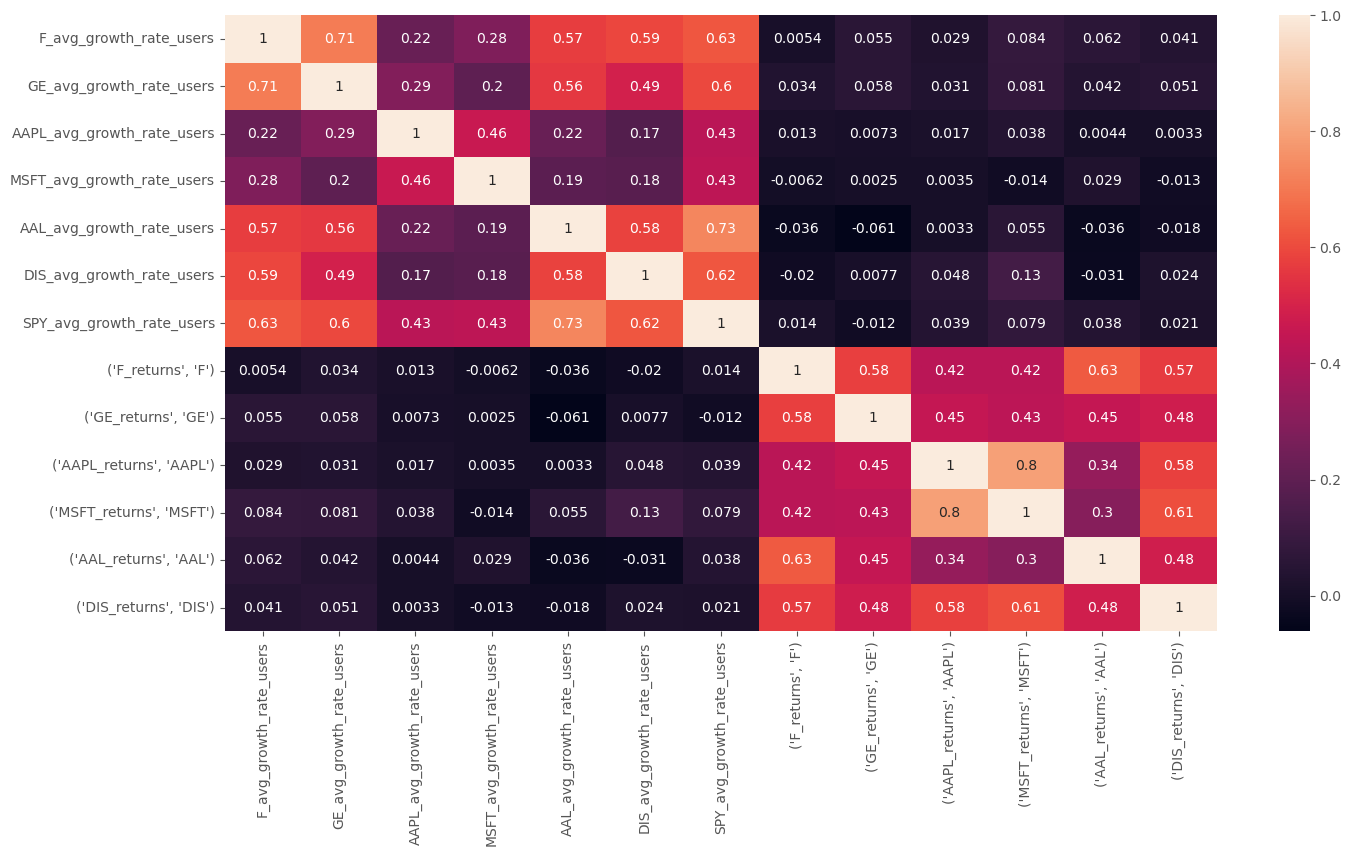

In [28]:
# Heatmap of the correlations

import seaborn as sns
plt.figure(figsize=(16,8))

sns.heatmap(daily_growth_returns_of_top_stocks.corr(), annot=True)

In [29]:
daily_growth_returns_of_top_stocks.to_csv(os.path.join(project_root,'master_panel.csv'))